In [1]:
# !pip install tenseal numpy scikit-learn pandas seaborn

## Klasyfikator binarny dla zbioru IRIS

In [2]:
import tenseal as ts
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
iris = load_iris()
MOD_DEG = 8192

X = iris.data[:100, :]
y = iris.target[:100]
print("Number of features: ", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Number of features:  4


In [4]:
model = LogisticRegression()

model.fit(X_train, y_train)

weights = model.coef_[0]
bias = model.intercept_[0]

print("Wytrenowane wagi:", weights)
print("Bias:", bias)

Wytrenowane wagi: [ 0.46248518 -0.84445753  2.21233212  0.92744332]
Bias: -6.524475408258978


In [5]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

context.global_scale = 2**40

context.generate_galois_keys()

In [6]:
sample = X_test[0]

print("Próbka testowa:")
print(sample)

encrypted_sample = ts.ckks_vector(context, sample)

Próbka testowa:
[6.  2.7 5.1 1.6]


In [7]:
encrypted_result = encrypted_sample.dot(weights) + bias

print("Zaszyfrowany wynik:")
print(encrypted_result)

Zaszyfrowany wynik:


In [8]:
decrypted_result = encrypted_result.decrypt()[0]

print("Odszyfrowany wynik:", decrypted_result)

predicted_class = int(decrypted_result > 0)

print("Przewidziana klasa:", predicted_class)
print("Prawdziwa klasa:", y_test[0])

Odszyfrowany wynik: 6.737205852645105
Przewidziana klasa: 1
Prawdziwa klasa: 1


## Klasyfikacja wieloklasowa dla zbioru IRIS

In [9]:
import tenseal as ts
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score

In [10]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [12]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [13]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

context.global_scale = 2**40

context.generate_galois_keys()

In [14]:
sample = X_test[0]
true_class = y_test[0]

print("Próbka testowa:")
print(sample)

encrypted_sample = ts.ckks_vector(context, sample)

Próbka testowa:
[6.1 2.8 4.7 1.2]


In [15]:
# Dla każdej klasy:
# score = w*x + b

encrypted_scores = []

for i in range(len(model.classes_)):

    weights = model.coef_[i]
    bias = model.intercept_[i]

    # obliczenia homomorficzne
    encrypted_score = encrypted_sample.dot(weights) + bias

    encrypted_scores.append(encrypted_score)

In [16]:
scores = []

for i, enc_score in enumerate(encrypted_scores):

    decrypted_score = enc_score.decrypt()[0]

    scores.append(decrypted_score)

    print(f"Wynik dla klasy {i}: {decrypted_score}")

Wynik dla klasy 0: -3.0577711568863264
Wynik dla klasy 1: 2.3248951377972418
Wynik dla klasy 2: 0.7328749459420072


In [17]:
predicted_class = np.argmax(scores)

print("Przewidziana klasa:", predicted_class)
print("Prawdziwa klasa:", true_class)

Przewidziana klasa: 1
Prawdziwa klasa: 1


In [18]:
predictions = []

for idx, sample in enumerate(X_test):

    true_class = y_test[idx]

    # Szyfrowanie próbki
    encrypted_sample = ts.ckks_vector(context, sample)

    # Klasyfikacja homomorficzna
    encrypted_scores = []

    for i in range(len(model.classes_)):
        weights = model.coef_[i]
        bias = model.intercept_[i]

        encrypted_score = encrypted_sample.dot(weights) + bias
        encrypted_scores.append(encrypted_score)

    # Odszyfrowanie wyników
    scores = []
    for enc_score in encrypted_scores:
        decrypted_score = enc_score.decrypt()[0]
        scores.append(decrypted_score)

    # Predykcja klasy
    predicted_class = np.argmax(scores)
    predictions.append(predicted_class)

#Metryki jakości klasyfikacji
predictions = np.array(predictions)
accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
F1-Score : 1.0000


## Wieloklasowy klasyfikator homomorficzny dla dużego zbioru MNIST

Ta sekcja korzysta z pełnego zbioru `mnist_784` z OpenML: 70000 obrazów cyfr zapisanych jako 784 cechy pikseli. Model liniowy jest trenowany na 60000 przykładach, testowany jawnie na 10000 obrazach, a następnie ten sam liniowy score jest liczony homomorficznie dla konfigurowalnego podzbioru testowego.

Pełny test homomorficzny dla 10000 obrazów wymagałby 10000 próbek x 10 klas x 784 cechy, dlatego domyślnie wykonywany jest zbalansowany podzbiór 1000 próbek. Inferencja CKKS może używać `multiprocessing` na Linuxie, ponieważ każda próbka testowa jest liczona niezależnie.

In [19]:

import os
import time
import multiprocessing as mp
import tenseal as ts
import numpy as np
import seaborn as sns

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


In [20]:
mnist_data = fetch_openml(
    name="mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
    data_home="./sklearn_data"
)

X_mnist = mnist_data.data.astype(np.float32) / 255.0
y_mnist = mnist_data.target.astype(np.int64)

# OpenML MNIST jest ulozony jak klasyczny MNIST: 60000 obrazow treningowych i 10000 testowych.
X_mnist_train = X_mnist[:60000]
X_mnist_test = X_mnist[60000:]
y_mnist_train = y_mnist[:60000]
y_mnist_test = y_mnist[60000:]

mnist_classes = np.array(sorted(np.unique(y_mnist)))

print("Zbior danych: OpenML mnist_784")
print("Liczba probek:", X_mnist.shape[0])
print("Liczba cech:", X_mnist.shape[1])
print("Rozmiar train/test:", X_mnist_train.shape, X_mnist_test.shape)
print("Klasy:", mnist_classes)
print("Rozklad klas w train:", dict(zip(mnist_classes, np.bincount(y_mnist_train))))


Zbior danych: OpenML mnist_784
Liczba probek: 70000
Liczba cech: 784
Rozmiar train/test: (60000, 784) (10000, 784)
Klasy: [0 1 2 3 4 5 6 7 8 9]
Rozklad klas w train: {np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}


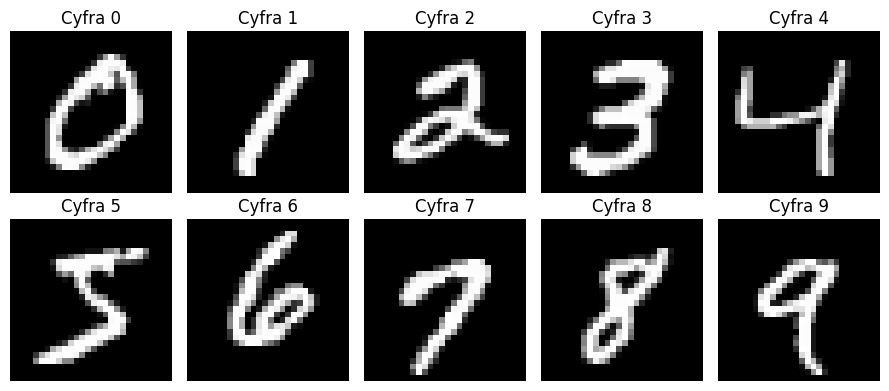

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for digit, ax in zip(mnist_classes, axes.ravel()):
    sample_idx = np.flatnonzero(y_mnist_train == digit)[0]
    ax.imshow(X_mnist_train[sample_idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Cyfra {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [22]:
mnist_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    max_iter=30,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

start_time = time.perf_counter()
mnist_model.fit(X_mnist_train, y_mnist_train)
train_time = time.perf_counter() - start_time

mnist_plain_predictions = mnist_model.predict(X_mnist_test)

print(f"Czas treningu modelu jawnego: {train_time:.2f} s")
print("Metryki modelu jawnego na pelnym tescie MNIST:")
print(f"Accuracy: {accuracy_score(y_mnist_test, mnist_plain_predictions):.4f}")
print(f"Precision weighted: {precision_score(y_mnist_test, mnist_plain_predictions, average='weighted', zero_division=0):.4f}")
print(f"Recall weighted: {recall_score(y_mnist_test, mnist_plain_predictions, average='weighted', zero_division=0):.4f}")
print(f"F1 weighted: {f1_score(y_mnist_test, mnist_plain_predictions, average='weighted', zero_division=0):.4f}")


Czas treningu modelu jawnego: 3.71 s
Metryki modelu jawnego na pelnym tescie MNIST:
Accuracy: 0.9155
Precision weighted: 0.9156
Recall weighted: 0.9155
F1 weighted: 0.9152


In [23]:
MNIST_MOD_DEG = 8192
mnist_context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=MNIST_MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
mnist_context.global_scale = 2**40
mnist_context.generate_galois_keys()

def encrypted_mnist_scores(sample):
    sample = np.asarray(sample, dtype=np.float64)
    encrypted_sample = ts.ckks_vector(mnist_context, sample)
    encrypted_scores = []
    for class_id in range(len(mnist_model.classes_)):
        weights = mnist_model.coef_[class_id].astype(np.float64)
        bias = float(mnist_model.intercept_[class_id])
        encrypted_scores.append(encrypted_sample.dot(weights) + bias)
    return encrypted_scores

def mnist_he_predict_one(task):
    sample_idx, sample, plain_scores = task
    encrypted_scores = encrypted_mnist_scores(sample)
    decrypted_scores = np.array([score.decrypt()[0] for score in encrypted_scores])
    encrypted_prediction = mnist_model.classes_[np.argmax(decrypted_scores)]
    plain_prediction = mnist_model.classes_[np.argmax(plain_scores)]
    return sample_idx, decrypted_scores, plain_scores, encrypted_prediction, plain_prediction


In [24]:
MNIST_HE_SAMPLES_PER_CLASS = 200
print(f"All samples: {len(mnist_classes) * MNIST_HE_SAMPLES_PER_CLASS}")

mnist_he_indices = []
for class_id in mnist_classes:
    print(class_id , end = ' ')
    class_indices = np.flatnonzero(y_mnist_test == class_id)
    mnist_he_indices.extend(class_indices[:MNIST_HE_SAMPLES_PER_CLASS])

mnist_he_indices = np.array(mnist_he_indices)
X_mnist_he_test = X_mnist_test[mnist_he_indices]
y_mnist_he_test = y_mnist_test[mnist_he_indices]

print("Liczba probek w tescie homomorficznym MNIST:", len(X_mnist_he_test))
print("Rozklad klas w tescie homomorficznym:", dict(zip(mnist_classes, np.bincount(y_mnist_he_test))))


All samples: 2000
0 1 2 3 4 5 6 7 8 9 Liczba probek w tescie homomorficznym MNIST: 2000
Rozklad klas w tescie homomorficznym: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}


In [25]:
MNIST_HE_USE_MULTIPROCESSING = os.name == "posix"
MNIST_HE_N_PROCESSES = min(4, os.cpu_count() or 1)
MNIST_HE_PROGRESS_EVERY = 25

if len(X_mnist_he_test) == 0:
    raise ValueError("Podzbior MNIST do testu homomorficznego jest pusty.")

mnist_plain_score_rows = mnist_model.decision_function(X_mnist_he_test)
total_mnist_he_samples = len(X_mnist_he_test)
mnist_tasks = [
    (sample_idx, X_mnist_he_test[sample_idx], mnist_plain_score_rows[sample_idx])
    for sample_idx in range(total_mnist_he_samples)
]
mnist_results = [None] * total_mnist_he_samples

start_time = time.perf_counter()

if MNIST_HE_USE_MULTIPROCESSING and MNIST_HE_N_PROCESSES > 1:
    chunksize = min(max(1, total_mnist_he_samples // (MNIST_HE_N_PROCESSES * 8)), 80)
    print(f"Start MNIST CKKS z multiprocessing: {MNIST_HE_N_PROCESSES} procesy, chunksize={chunksize}")
    mp_context = mp.get_context("fork")
    with mp_context.Pool(processes=MNIST_HE_N_PROCESSES, maxtasksperchild=50) as pool:
        iterator = pool.imap_unordered(mnist_he_predict_one, mnist_tasks, chunksize=chunksize)
        for processed_count, result in enumerate(iterator, start=1):
            sample_idx, decrypted_scores, plain_scores, encrypted_prediction, plain_prediction = result
            mnist_results[sample_idx] = (
                decrypted_scores,
                plain_scores,
                encrypted_prediction,
                plain_prediction,
            )
            if processed_count == 1 or processed_count == total_mnist_he_samples or processed_count % MNIST_HE_PROGRESS_EVERY == 0:
                print(f"Przetworzono {processed_count}/{total_mnist_he_samples} probek MNIST CKKS")
else:
    print("Start MNIST CKKS w trybie sekwencyjnym")
    for processed_count, task in enumerate(mnist_tasks, start=1):
        sample_idx, decrypted_scores, plain_scores, encrypted_prediction, plain_prediction = mnist_he_predict_one(task)
        mnist_results[sample_idx] = (
            decrypted_scores,
            plain_scores,
            encrypted_prediction,
            plain_prediction,
        )
        if processed_count == 1 or processed_count == total_mnist_he_samples or processed_count % MNIST_HE_PROGRESS_EVERY == 0:
            print(f"Przetworzono {processed_count}/{total_mnist_he_samples} probek MNIST CKKS")

he_time = time.perf_counter() - start_time

mnist_decrypted_scores = np.array([result[0] for result in mnist_results])
mnist_plain_scores = np.array([result[1] for result in mnist_results])
mnist_encrypted_predictions = np.array([result[2] for result in mnist_results])
mnist_plain_subset_predictions = np.array([result[3] for result in mnist_results])
mnist_score_errors = np.abs(mnist_decrypted_scores - mnist_plain_scores)

print("Metryki klasyfikacji homomorficznej MNIST na podzbiorze testowym:")
print(f"Accuracy: {accuracy_score(y_mnist_he_test, mnist_encrypted_predictions):.4f}")
print(f"Precision weighted: {precision_score(y_mnist_he_test, mnist_encrypted_predictions, average='weighted', zero_division=0):.4f}")
print(f"Recall weighted: {recall_score(y_mnist_he_test, mnist_encrypted_predictions, average='weighted', zero_division=0):.4f}")
print(f"F1 weighted: {f1_score(y_mnist_he_test, mnist_encrypted_predictions, average='weighted', zero_division=0):.4f}")
print(f"Zgodnosc z modelem jawnym: {accuracy_score(mnist_plain_subset_predictions, mnist_encrypted_predictions):.4f}")
print(f"Maksymalny blad score CKKS: {mnist_score_errors.max():.8f}")
print(f"Sredni blad score CKKS: {mnist_score_errors.mean():.8f}")
print(f"Calkowity czas klasyfikacji homomorficznej: {he_time:.2f} s")
print(f"Sredni czas na probke: {he_time / total_mnist_he_samples:.4f} s")


Start MNIST CKKS z multiprocessing: 4 procesy, chunksize=62


Przetworzono 1/2000 probek MNIST CKKS
Przetworzono 25/2000 probek MNIST CKKS
Przetworzono 50/2000 probek MNIST CKKS
Przetworzono 75/2000 probek MNIST CKKS
Przetworzono 100/2000 probek MNIST CKKS
Przetworzono 125/2000 probek MNIST CKKS
Przetworzono 150/2000 probek MNIST CKKS
Przetworzono 175/2000 probek MNIST CKKS
Przetworzono 200/2000 probek MNIST CKKS
Przetworzono 225/2000 probek MNIST CKKS
Przetworzono 250/2000 probek MNIST CKKS
Przetworzono 275/2000 probek MNIST CKKS
Przetworzono 300/2000 probek MNIST CKKS
Przetworzono 325/2000 probek MNIST CKKS
Przetworzono 350/2000 probek MNIST CKKS
Przetworzono 375/2000 probek MNIST CKKS
Przetworzono 400/2000 probek MNIST CKKS
Przetworzono 425/2000 probek MNIST CKKS
Przetworzono 450/2000 probek MNIST CKKS
Przetworzono 475/2000 probek MNIST CKKS
Przetworzono 500/2000 probek MNIST CKKS
Przetworzono 525/2000 probek MNIST CKKS
Przetworzono 550/2000 probek MNIST CKKS
Przetworzono 575/2000 probek MNIST CKKS
Przetworzono 600/2000 probek MNIST CKKS
Przet

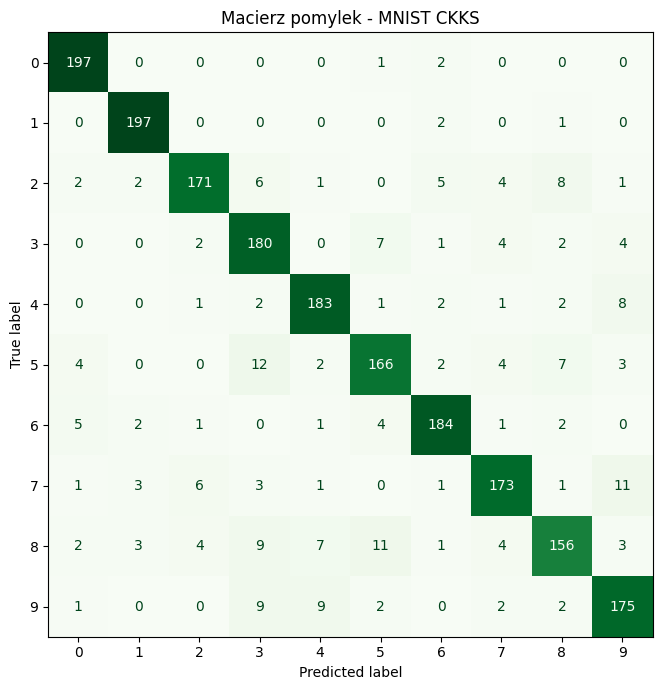

In [26]:
mnist_cm = confusion_matrix(
    y_mnist_he_test,
    mnist_encrypted_predictions,
    labels=mnist_classes
)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=mnist_cm,
    display_labels=mnist_classes
)
disp.plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
ax.set_title("Macierz pomylek - MNIST CKKS")
plt.tight_layout()
plt.savefig("mnist_macierz_pomylek_he.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
mnist_he_accuracy = accuracy_score(y_mnist_he_test, mnist_encrypted_predictions)
mnist_he_precision = precision_score(
    y_mnist_he_test,
    mnist_encrypted_predictions,
    average="weighted",
    zero_division=0
)
mnist_he_recall = recall_score(
    y_mnist_he_test,
    mnist_encrypted_predictions,
    average="weighted",
    zero_division=0
)
mnist_he_f1 = f1_score(
    y_mnist_he_test,
    mnist_encrypted_predictions,
    average="weighted",
    zero_division=0
)
mnist_plain_agreement = accuracy_score(
    mnist_plain_subset_predictions,
    mnist_encrypted_predictions
)

print("Metryki MNIST po odszyfrowaniu wynikow:")
print(f"Liczba probek testowych: {len(y_mnist_he_test)}")
print(f"Accuracy: {mnist_he_accuracy:.4f}")
print(f"Precision weighted: {mnist_he_precision:.4f}")
print(f"Recall weighted: {mnist_he_recall:.4f}")
print(f"F1 weighted: {mnist_he_f1:.4f}")


Metryki MNIST po odszyfrowaniu wynikow:
Liczba probek testowych: 2000
Accuracy: 0.8910
Precision weighted: 0.8913
Recall weighted: 0.8910
F1 weighted: 0.8904


In [33]:
mnist_plain_direct_predictions = mnist_model.predict(X_mnist_he_test)

mnist_plain_direct_metrics = {
    "Accuracy": accuracy_score(y_mnist_he_test, mnist_plain_direct_predictions),
    "Precision weighted": precision_score(
        y_mnist_he_test,
        mnist_plain_direct_predictions,
        average="weighted",
        zero_division=0
    ),
    "Recall weighted": recall_score(
        y_mnist_he_test,
        mnist_plain_direct_predictions,
        average="weighted",
        zero_division=0
    ),
    "F1 weighted": f1_score(
        y_mnist_he_test,
        mnist_plain_direct_predictions,
        average="weighted",
        zero_division=0
    ),
}

mnist_he_metrics = {
    "Accuracy": accuracy_score(y_mnist_he_test, mnist_encrypted_predictions),
    "Precision weighted": precision_score(
        y_mnist_he_test,
        mnist_encrypted_predictions,
        average="weighted",
        zero_division=0
    ),
    "Recall weighted": recall_score(
        y_mnist_he_test,
        mnist_encrypted_predictions,
        average="weighted",
        zero_division=0
    ),
    "F1 weighted": f1_score(
        y_mnist_he_test,
        mnist_encrypted_predictions,
        average="weighted",
        zero_division=0
    ),
}

mnist_direct_agreement = accuracy_score(
    mnist_plain_direct_predictions,
    mnist_encrypted_predictions
)
mnist_prediction_differences = np.flatnonzero(
    mnist_plain_direct_predictions != mnist_encrypted_predictions
)

print("Metryki modelu jawnego MNIST na tym samym zbiorze testowym:")
print(f"Liczba probek testowych: {len(y_mnist_he_test)}")
for metric_name, metric_value in mnist_plain_direct_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print(f"\nZgodnosc predykcji jawnych i zaszyfrowanych: {mnist_direct_agreement:.4f}")
print(f"Liczba roznych predykcji: {len(mnist_prediction_differences)}")

if len(mnist_prediction_differences) > 0:
    print("Pierwsze rozne predykcje: idx, prawdziwa, jawna, zaszyfrowana")
    for idx in mnist_prediction_differences[:10]:
        print(idx, y_mnist_he_test[idx], mnist_plain_direct_predictions[idx], mnist_encrypted_predictions[idx])


Metryki modelu jawnego MNIST na tym samym zbiorze testowym:
Liczba probek testowych: 2000
Accuracy: 0.8910
Precision weighted: 0.8913
Recall weighted: 0.8910
F1 weighted: 0.8904

Zgodnosc predykcji jawnych i zaszyfrowanych: 1.0000
Liczba roznych predykcji: 0
